In [16]:
from astropy.io import fits
# import pyregion
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy import constants as cte 
import regions
from astropy.nddata import Cutout2D
from astropy.coordinates import Angle
from astropy.table import QTable, Table
from astropy.coordinates import SkyCoord
from astropy.modeling import models, fitting
from astropy.modeling.models import Const1D
FITTER = fitting.LevMarLSQFitter()
from discrete_gaussian_model import DiscreteGaussianModel
import pandas as pd
from scipy.signal import find_peaks

First, we call the data with the mean spectrum of the three regions. The files are called 'Lambda_NIRSpec_region1.ecsv' and 'Flux_NIRSpec_Region1.ecsv'. Lambda is for the wavelengths (in microns) and Flux is for the flux (in MJy/sr). If we want to check another region, just change the number.

In [2]:
Lamb = QTable.read('Lambda_NIRSpec_Region1.ecsv')
Lamb

N_1,N_2,N_3
um,um,um
float64[3610],float64[3915],float64[3814]
2.8703323855588674 .. 5.270317384012739,0.0 .. 0.0,0.0 .. 0.0
0.0 .. 0.0,0.9701175286099896 .. 1.88990752673271,0.0 .. 0.0
0.0 .. 0.0,0.0 .. 0.0,1.6601979666156694 .. 3.170145922922529


In [3]:
Flux = QTable.read('Flux_NIRSpec_Region1.ecsv')
Flux

N_1,N_2,N_3
MJy / sr,MJy / sr,MJy / sr
float32[3610],float32[3915],float32[3814]
22.962223052978516 .. 99.76720428466797,0.0 .. 0.0,0.0 .. 0.0
0.0 .. 0.0,7.746485233306885 .. 12.545706748962402,0.0 .. 0.0
0.0 .. 0.0,0.0 .. 0.0,8.681315422058105 .. nan


If we want to compare the F187N filter with the spectrum, in this case we will use the column 'N_3'. Both have units: microns for wavelength and MJy/sr for flux.

(1, 20000.0)

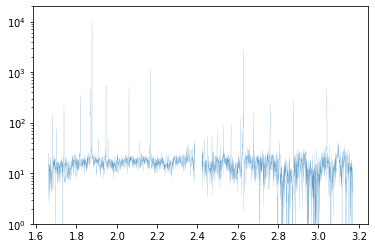

In [4]:
plt.plot(Lamb['N_3'][2].value,Flux['N_3'][2].value, lw=0.1)
ax = plt.gca()
ax.set_yscale("log")
ax.set_ylim(1, 2e4)

This are the lambda and the spectrum that we are going to work

In [10]:
x = Lamb['N_3'][2] # This is lambda
y = Flux['N_3'][2] # This is the flux

Now, we call the filter that we are going to work

In [13]:
'''The throughput of F187N'''
T_F187N = pd.read_csv('/home/roberto/MAST_2026-07-31T01_03_53.583Z/nircam_throughput/detector_based_throughputs/NRCB3_F187N_system_throughput.txt', sep=' ', skiprows=1,header=None)

The class

In [14]:
class FilterSpectrum:
    '''Spectrum in a certain filter'''
    
    def __init__(self,lamb_Spec,flux_Spec,lamb_Filter,trou_Filter,factor = 0.1):
        self.lambda_unit = lamb_Spec.unit
        self.flux_unit = flux_Spec.unit
        self.lamb_min = lamb_Filter[0]
        self.lamb_max = lamb_Filter[len(lamb_Filter)-1]
        self.cut(self.lamb_min,self.lamb_max,lamb_Spec.value,flux_Spec.value)
        self.pix_width = self.x[1]-self.x[0]
        self.weight_x = np.array([i for i in lamb_Filter])
        self.weight_y = np.array([factor*max(self.y)*i for i in trou_Filter])
        self.finding_peaks(self.y)
        self.peaks_mean = self.x[self.peaks_idx]
        self.peaks_amplitudes = self.peaks_info['prominences']
        
    def cut(self,lambda_min,lambda_max,lambda_Spec,flux_Spec):
        idx_min, idx_max = 0, 0
        while lambda_Spec[idx_min] < lambda_min:
            idx_min = idx_min + 1
        while lambda_Spec[idx_max] < lambda_max:
            idx_max = idx_max + 1
        self.x = lambda_Spec[idx_min:idx_max]
        self.y = flux_Spec[idx_min:idx_max]
        
    def finding_peaks(self,flux):
        flux_max = max(flux)
        self.peaks_idx, self.peaks_info = find_peaks(flux,prominence=(0.01*flux_max,flux_max),height=0)

In [17]:
example = FilterSpectrum(x,y,T_F187N[0],T_F187N[1])

# Model

In [19]:
def fit_to_Spec(lamb_Spec,flux_Spec,Amplitudes,Means,Step_wave,continuum = Const1D(amplitude=10),Stddev=0.00025):
    model = continuum
    
    for i in range(len(Amplitudes)):
        '''Each Gaussian represents each important line emission'''
        lim_mean = float(format(Means[i],'.3f'))
        gi = DiscreteGaussianModel(
            amplitude=Amplitudes[i], mean=Means[i], stddev=Stddev, 
            bin_width=Step_wave, fixed={"bin_width": True},
            )
        
        gi.mean.bounds = lim_mean , lim_mean+.01
        gi.stddev.bounds = 0.00001,0.001
        model = model + gi
    
    Model = FITTER(model, lamb_Spec,flux_Spec)
    return(Model)

S'i' correspond to Sigma'i'

M'i' correspond to Mean'i'

A'i' correspond to Amplitude'i'

In [20]:
fit_example = fit_to_Spec(example.x,example.y,example.peaks_amplitudes,example.peaks_mean,example.pix_width)

(0.0, 600.0)

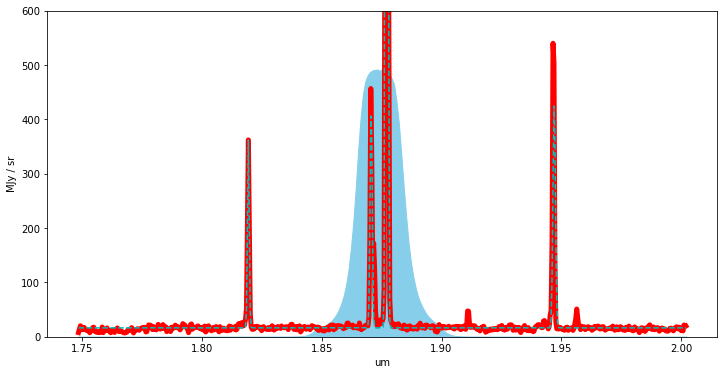

In [22]:
plt.figure(figsize=(12,6))
plt.fill_between(example.weight_x,example.weight_y,color='skyblue')
plt.plot(example.x,example.y,linewidth = 5, color ='r')
plt.plot(example.x,fit_example(example.x),'--',color='c')
plt.ylabel(f'{example.flux_unit}')
plt.xlabel(f'{example.lambda_unit}')
plt.ylim(0,600)

Example for F200W

In [23]:
T_F200W = pd.read_csv('/home/roberto/MAST_2026-07-31T01_03_53.583Z/nircam_throughput/detector_based_throughputs/NRCB3_F200W_system_throughput.txt', sep=' ', skiprows=1,header=None)
exa_200 = FilterSpectrum(x,y,T_F200W[0],T_F200W[1])
fit_200 = fit_Spec(exa_200.x,exa_200.y,exa_200.peaks_amplitudes,exa_200.peaks_mean,exa_200.pix_width)

(0.0, 600.0)

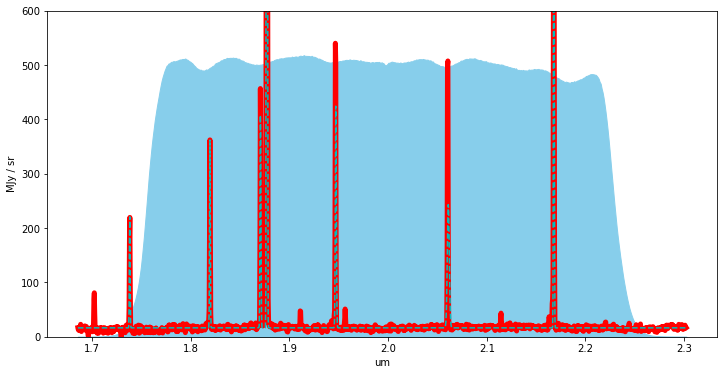

In [24]:
plt.figure(figsize=(12,6))
plt.fill_between(exa_200.weight_x,exa_200.weight_y,color='skyblue')
plt.plot(exa_200.x,exa_200.y,linewidth = 5, color ='r')
plt.plot(exa_200.x,fit_200(exa_200.x),'--',color='c')
plt.ylabel(f'{exa_200.flux_unit}')
plt.xlabel(f'{exa_200.lambda_unit}')
plt.ylim(0,600)

From here, te code was for an other example

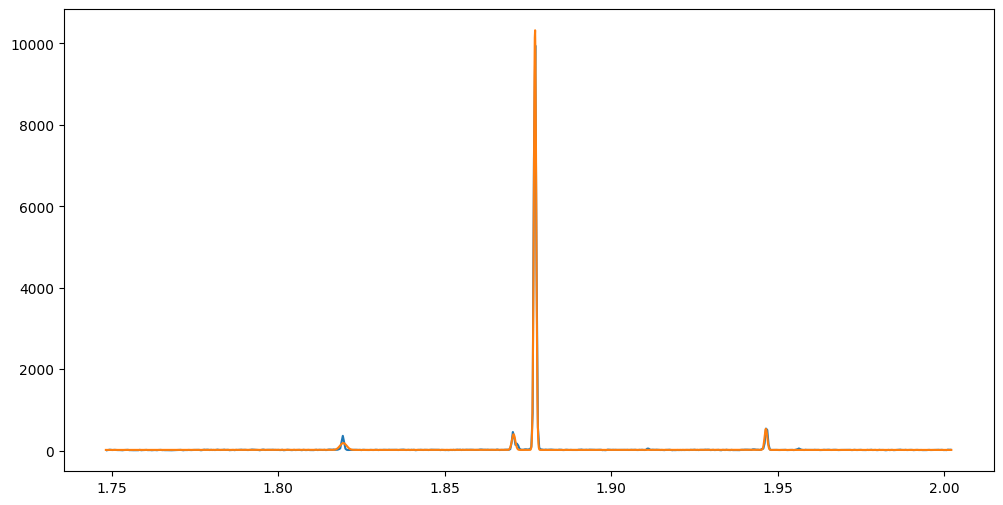

In [46]:
rgrid = np.linspace(1.7482,2.0022,2530)

plt.figure(figsize=(12, 6))
plt.plot(x.value,y.value)
plt.plot(rgrid,Model(rgrid))
plt.show()

Zoom on Pa alpha line

(1.86, 1.89)

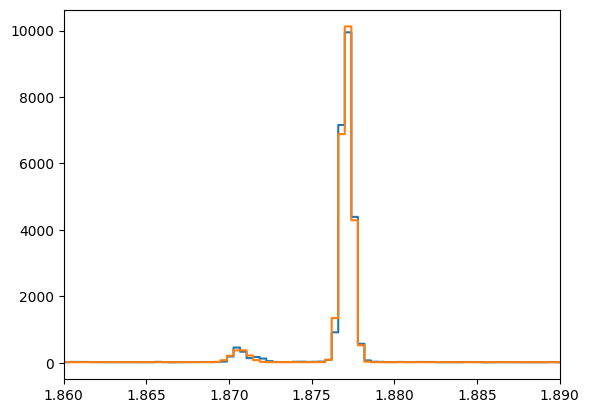

In [47]:
fig, ax = plt.subplots()
ax.plot(x.value, y.value, ds="steps-mid")
ax.plot(x.value, Model(x.value), ds="steps-mid")
ax.set_xlim(1.86, 1.89)

(1.81, 1.83)

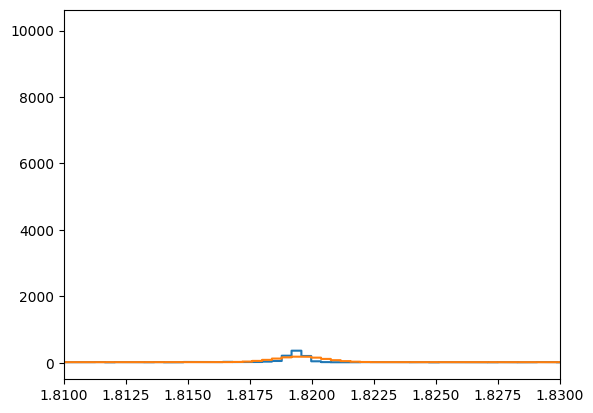

In [48]:
fig, ax = plt.subplots()
ax.plot(x.value, y.value, ds="steps-mid")
ax.plot(x.value, Model(x.value), ds="steps-mid")
ax.set_xlim(1.81, 1.83)

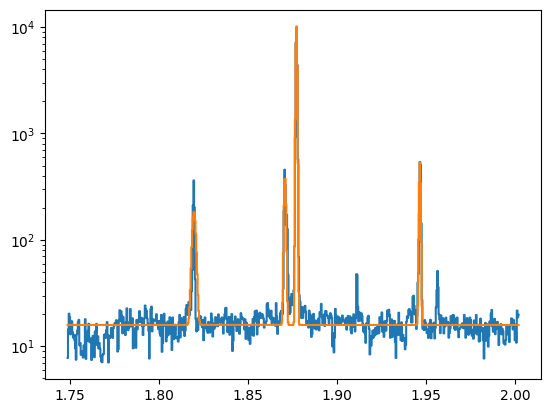

In [49]:
fig, ax = plt.subplots()
ax.plot(x.value, y.value, ds="steps-mid")
ax.plot(x.value, Model(x.value), ds="steps-mid")
ax.set_yscale("log")
# ax.set_xlim(1.81, 1.83)

In [42]:
print(Model)

Model: CompoundModel
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Expression: [0] + [1] + [2] + [3] + [4]
Components: 
    [0]: <DiscreteGaussianModel(amplitude=841.37832444, mean=1.819, stddev=0.00059106, bin_width=0.000396)>

    [1]: <DiscreteGaussianModel(amplitude=1231.52352817, mean=1.87065114, stddev=0.00049498, bin_width=0.000396)>

    [2]: <DiscreteGaussianModel(amplitude=23180.01914787, mean=1.87713081, stddev=0.00033458, bin_width=0.000396)>

    [3]: <DiscreteGaussianModel(amplitude=1351.47770742, mean=1.9465, stddev=0.00039588, bin_width=0.000396)>

    [4]: <Const1D(amplitude=16.28016128)>
Parameters:
       amplitude_0    mean_0 ... bin_width_3    amplitude_4    
    ----------------- ------ ... ----------- ------------------
    841.3783244425874  1.819 ...    0.000396 16.280161281538756
